## Are codes actually getting more efficient as we progress through a network?

In [12]:
from models import NoisyMLP, ActivationLogger
from data import MNISTDataModule
import numpy as np
import torch
import wandb
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import WandbLogger
from accelerate.test_utils.testing import get_backend

# plotting
import matplotlib.pyplot as plt

# set up logger
wandb_logger = WandbLogger(project="efficient-coding")
# get device information
device, n_devices, mem = get_backend()
# set precision for matmul to high, recommended for training
torch.set_float32_matmul_precision("high")
# Set custom plotting style
plt.style.use("~/clean-figs.mplstyle")

ImportError: cannot import name 'ActivationLogger' from 'models' (~/efficient-coding/models.py)

In [ ]:
model = NoisyMLP()

mnist = MNISTDataModule(batch_size=32)
trainer = Trainer(max_epochs=100,
                  logger=wandb_logger, 
                  callbacks=[EarlyStopping(monitor="val/loss"), 
                             ActivationLogger(log_every_n_epochs=1)])

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: <wandb-user> (<wandb-entity>) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
~/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python ~/.cache/pypoetry/virtualenvs/efficient ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [4]:
# def get_activation_hook(name, activation_dict):
#     """Returns a function that will store the output of a layer in a dictionary."""
#     def hook(model, input, output):
#         activation_dict[name] = output.detach()
#     return hook


# model.eval()

# # Dictionary to store the activations
# activations = {}

# # Register forward hooks on the layers you care about
# # For instance, let's hook after each Linear
# for idx, layer in enumerate(model.layers):
#     if isinstance(layer, torch.nn.ReLU):
#         layer.register_forward_hook(get_activation_hook(f"layer_{idx}", activations))

In [5]:
trainer.fit(model, datamodule=mnist)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 151 K  | train
----------------------------------------------
151 K     Trainable params
0         Non-trainable params
151 K     Total params
0.605     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

~/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
~/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [8]:
api = wandb.Api()
run = api.run("<wandb-entity>/efficient-coding/i2x59z35")
history = run.history()
activation_data = history[['epoch', 'activations/linear_0_mean', 'activations/linear_0_std', 'activations/linear_0_entropy']]
valid_data = activation_data.dropna()

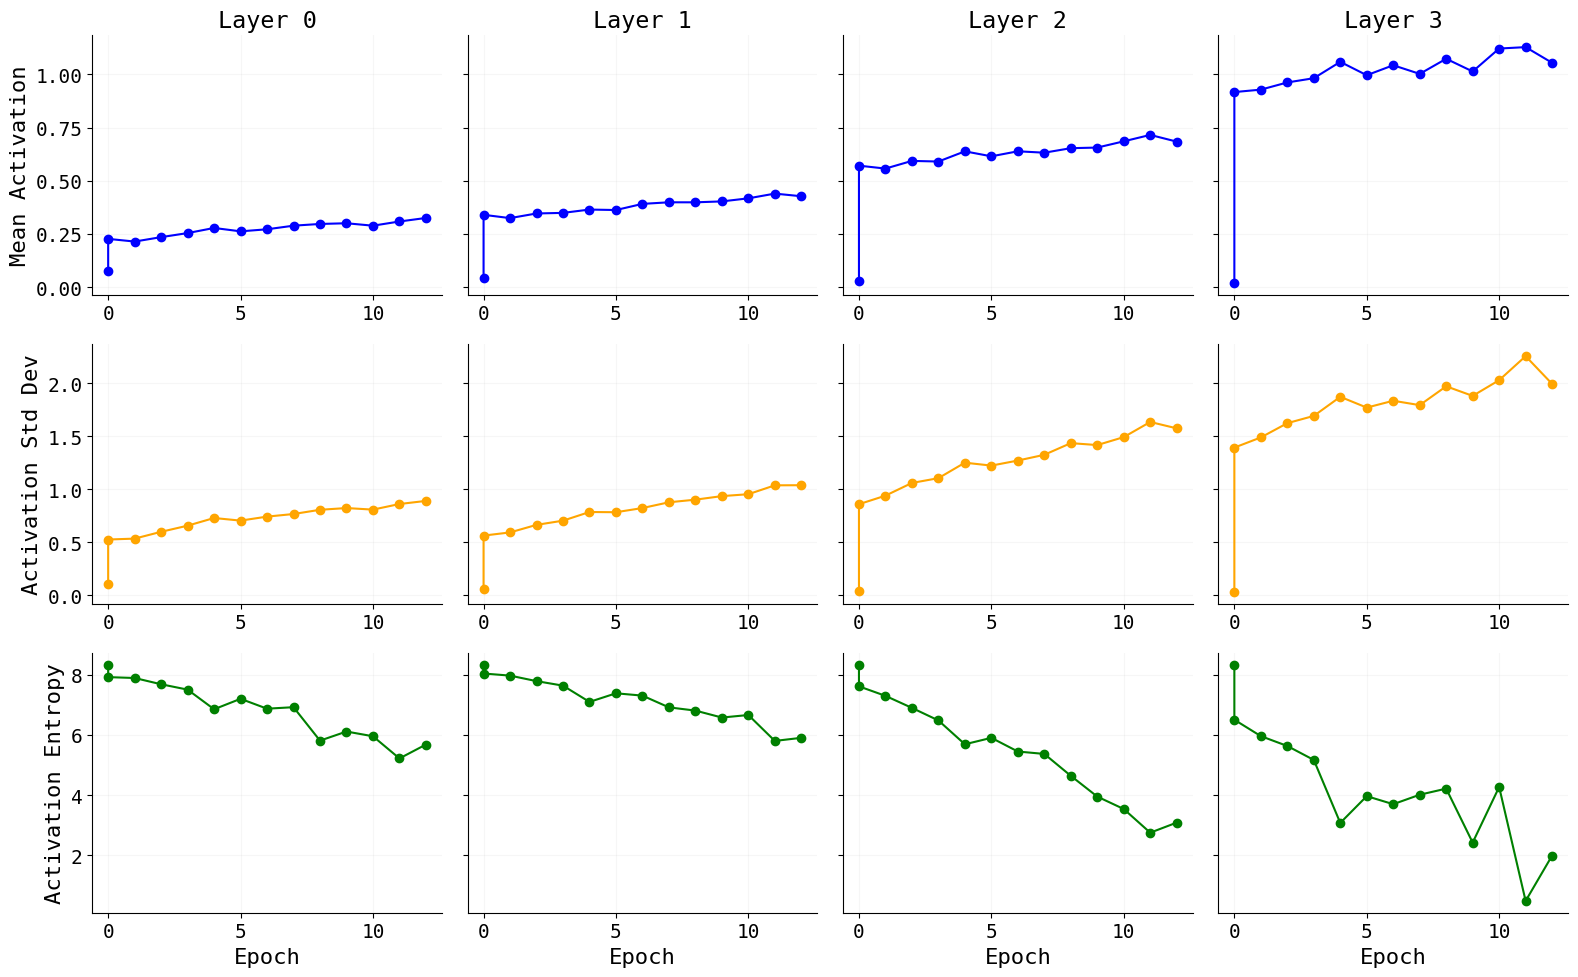

In [9]:
# First, let's determine how many layers we have by looking at column names
layer_indices = set()
for col in history.columns:
    if col.startswith('activations/linear_') and col.endswith('_mean'):
        # Extract the layer index from the column name
        layer_idx = int(col.split('_')[1])
        layer_indices.add(layer_idx)

# Sort the indices
layer_indices = sorted(layer_indices)
num_layers = len(layer_indices)

# Create a figure with a 3xN grid (3 metrics, N layers)
fig, axes = plt.subplots(3, num_layers, figsize=(4*num_layers, 10), sharey='row')

# Metrics to plot
metrics = ['mean', 'std', 'entropy']
metric_colors = ['blue', 'orange', 'green']
metric_titles = ['Mean Activation', 'Activation Std Dev', 'Activation Entropy']

# Plot each layer's metrics in columns
for col_idx, layer_idx in enumerate(layer_indices):
    layer_name = f'linear_{layer_idx}'
    
    # For each metric (row)
    for row_idx, (metric, color, title) in enumerate(zip(metrics, metric_colors, metric_titles)):
        col_name = f'activations/{layer_name}_{metric}'
        
        # Get data for this layer and metric, dropping NaNs
        valid_layer_data = history[['epoch', col_name]].dropna()
        
        # Get the axis for this subplot
        ax = axes[row_idx, col_idx]
        
        # Plot the data
        ax.plot(valid_layer_data['epoch'], valid_layer_data[col_name], 'o-', color=color)
        
        # Set titles and labels
        if row_idx == 0:
            ax.set_title(f'Layer {layer_idx}')
        if col_idx == 0:
            ax.set_ylabel(title)
        if row_idx == 2:
            ax.set_xlabel('Epoch')
        
        ax.grid(True)

plt.tight_layout()
plt.show()

In [53]:
import scipy
print(scipy.stats.entropy([1, 2, 3, 4]))
print(scipy.stats.entropy(scipy.special.softmax([1, 2, 3, 4])))
print(scipy.stats.entropy([.25, .25, .25, .25]))

1.2798542258336676
0.9475369639754254
1.3862943611198906


Layer 0, Epoch 0
{'count': 64, 'min': 0, 'size': 0.01271617691963911}
Layer 1, Epoch 0
{'size': 0.006526210345327854, 'count': 64, 'min': 0}
Layer 2, Epoch 0
{'size': 0.003083310555666685, 'count': 64, 'min': 0}
Layer 3, Epoch 0
{'count': 64, 'min': 0, 'size': 0.002389115747064352}
Layer 0, Epoch 3
{'min': 0, 'size': 0.07979722321033478, 'count': 64}
Layer 1, Epoch 3
{'count': 64, 'min': 0, 'size': 0.07073149085044861}
Layer 2, Epoch 3
{'min': 0, 'size': 0.10439538955688477, 'count': 64}
Layer 3, Epoch 3
{'min': 0, 'size': 0.1496373564004898, 'count': 64}
Layer 0, Epoch 6
{'min': 0, 'size': 0.0964907631278038, 'count': 64}
Layer 1, Epoch 6
{'min': 0, 'size': 0.0880555585026741, 'count': 64}
Layer 2, Epoch 6
{'min': 0, 'size': 0.13246317207813263, 'count': 64}
Layer 3, Epoch 6
{'min': 0, 'size': 0.18712690472602844, 'count': 64}
Layer 0, Epoch 9
{'min': 0, 'size': 0.10551517456769943, 'count': 64}
Layer 1, Epoch 9
{'min': 0, 'size': 0.10555590689182281, 'count': 64}
Layer 2, Epoch 9
{'s

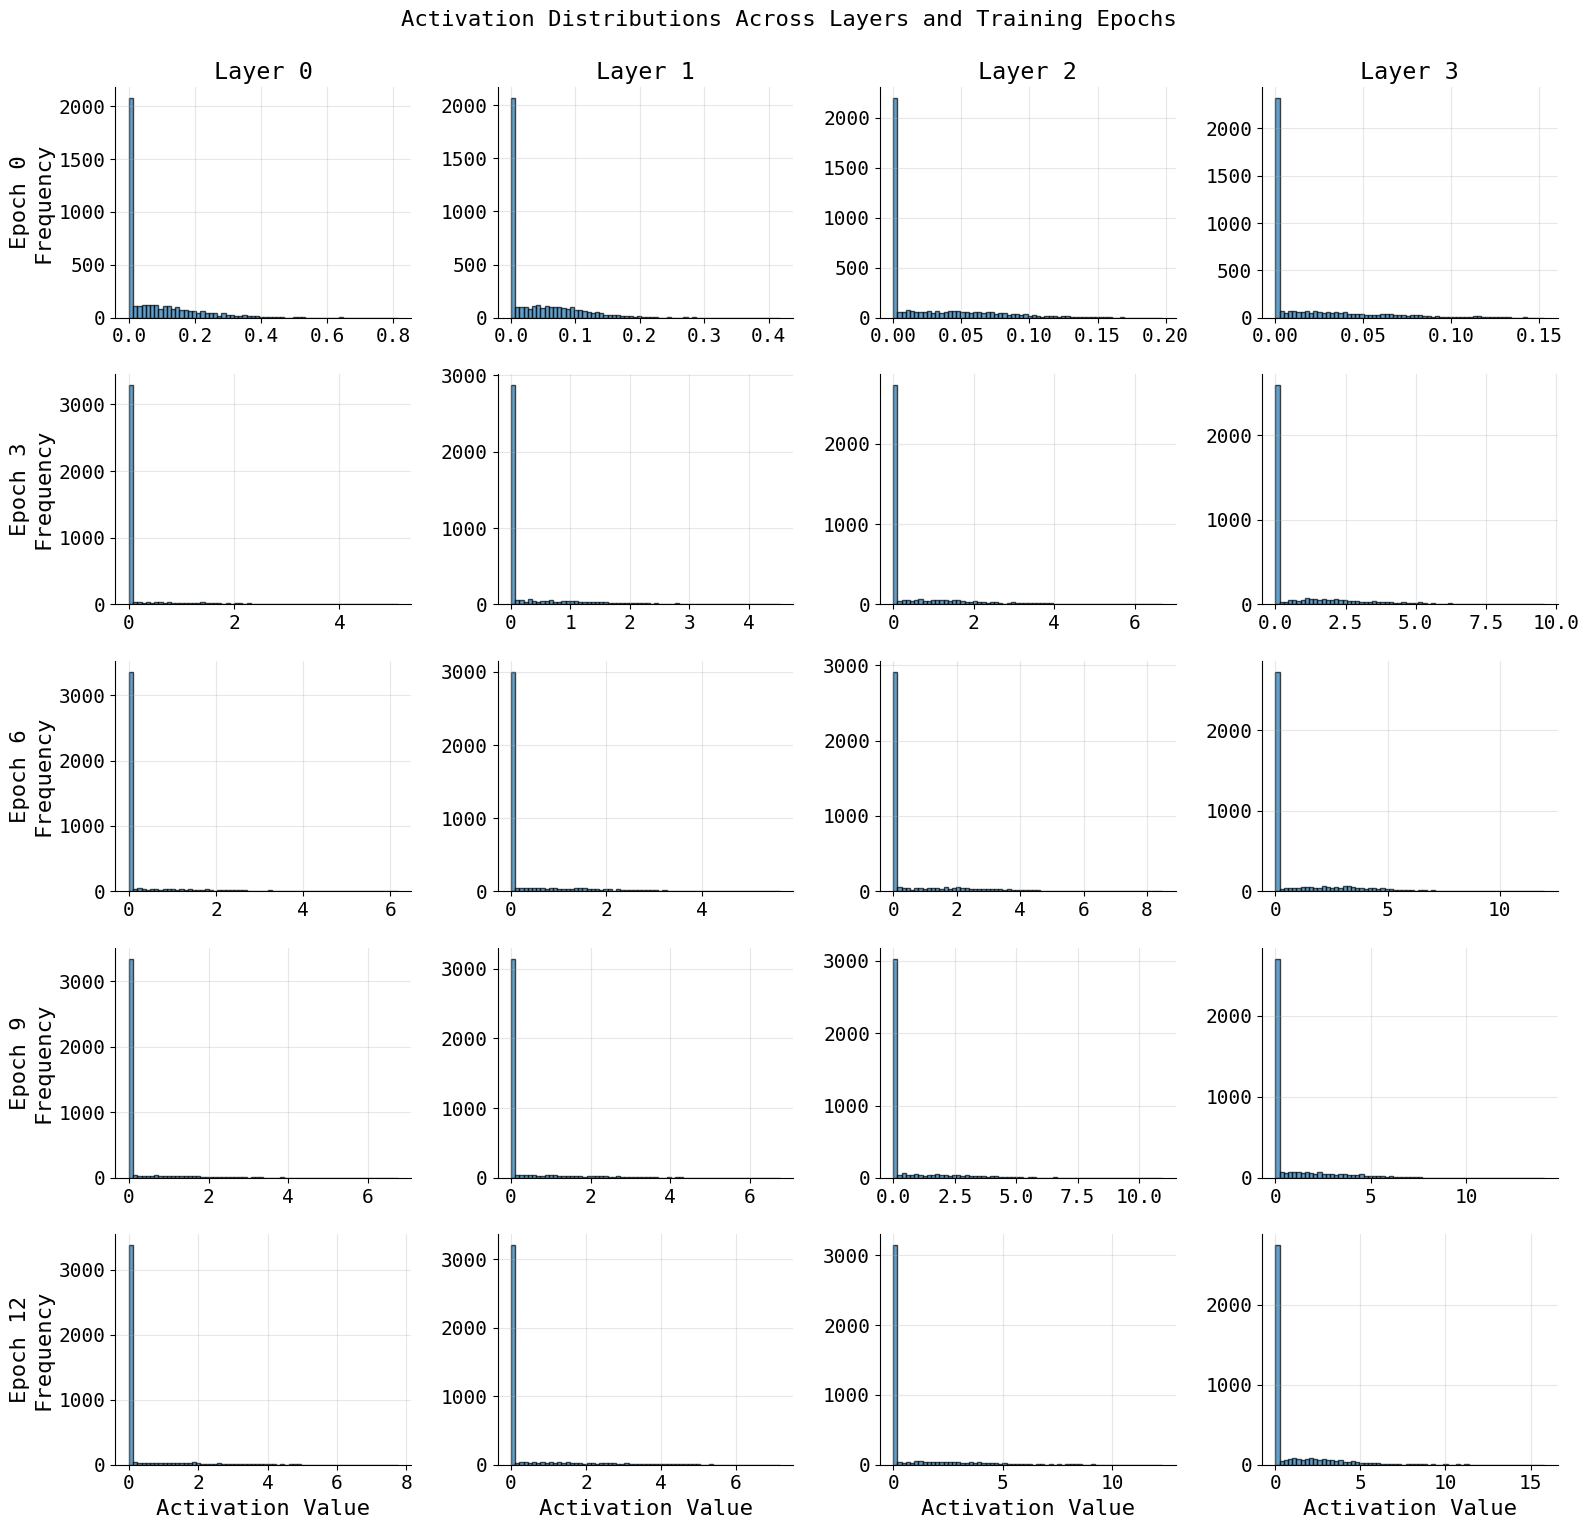

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# First, identify all layers and epochs with histogram data
layer_indices = set()
epochs = set()

for col in history.columns:
    if col.startswith('activations/linear_') and not any(suffix in col for suffix in ['_mean', '_std', '_entropy']):
        # Extract the layer index
        layer_idx = int(col.split('_')[1])
        layer_indices.add(layer_idx)

# Get all epochs with activation data
for i, row in history.iterrows():
    if not pd.isna(row.get('activations/linear_0')):
        epochs.add(row['epoch'])

# Convert to sorted lists
layer_indices = sorted(layer_indices)
epochs = sorted(list(epochs))

# Select up to 5 epochs to display (first, last, and 3 in between)
if len(epochs) > 5:
    selected_epochs = [epochs[0], epochs[len(epochs)//4], epochs[len(epochs)//2], 
                      epochs[3*len(epochs)//4], epochs[-1]]
else:
    selected_epochs = epochs

# Create figure with subplots
fig, axes = plt.subplots(len(selected_epochs), len(layer_indices), 
                         figsize=(4*len(layer_indices), 3*len(selected_epochs)),
                        # sharex=True, sharey=True,
                         squeeze=False)

# Plot histograms
for row_idx, epoch in enumerate(selected_epochs):
    # Get the data for this epoch
    epoch_data = history[history['epoch'] == epoch]
    
    for col_idx, layer_idx in enumerate(layer_indices):
        ax = axes[row_idx, col_idx]
        layer_name = f'activations/linear_{layer_idx}'
        print(f"Layer {layer_idx}, Epoch {epoch}")
        
        # Check if we have data for this layer and epoch
        hist_data = epoch_data[layer_name].dropna().iloc[0]
        
        # Extract bin information
        if "packedBins" in hist_data:
            binspec = hist_data["packedBins"]
            print(binspec)
        bin_values = hist_data.get("values")
        
        if binspec and bin_values:
            bin_edges = np.arange(binspec['count'] + 1) * binspec['size'] + binspec['min']
            ax.bar(bin_edges[:-1], bin_values, width=binspec['size'], 
                    align='edge', edgecolor='black', alpha=0.7)
            
            # Set x-axis limits consistently across epochs for the same layer
            # if row_idx == 0:
            #     # Save the limits from the first epoch
            #     x_min, x_max = ax.get_xlim()
            # else:
            #     # Apply consistent limits
            #     ax.set_xlim(x_min, x_max)
        
        # Add labels and titles
        if row_idx == 0:
            ax.set_title(f'Layer {layer_idx}')
        if col_idx == 0:
            ax.set_ylabel(f'Epoch {int(epoch)}\nFrequency')
        if row_idx == len(selected_epochs) - 1:
            ax.set_xlabel('Activation Value')
        
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Activation Distributions Across Layers and Training Epochs', y=1.02, fontsize=16)
plt.show()